In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np 
%matplotlib inline

Matplotlib is building the font cache; this may take a moment.


In [23]:
df = pd.read_csv('height-weight.csv')

In [25]:
df.head()

,weight_kg,height_cm
0,45,150
1,48,152
2,50,155
3,52,158
4,55,160


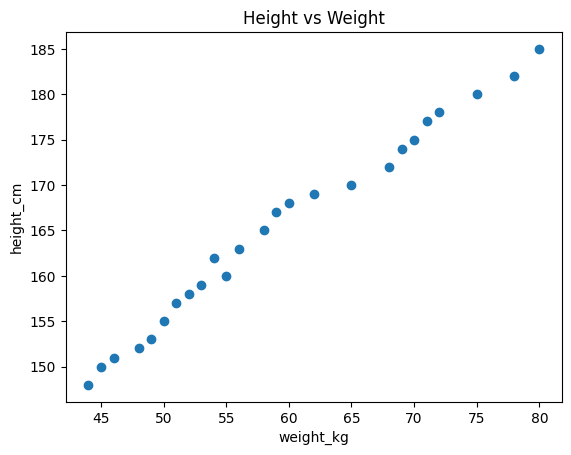

In [27]:
## scatter plot 
plt.scatter(df['weight_kg'] , df['height_cm'])
plt.xlabel('weight_kg')
plt.ylabel('height_cm')
plt.title('Height vs Weight')
plt.show()

In [28]:
## Correlation coefficient 
df.corr()

,weight_kg,height_cm
weight_kg,1.00000,0.99289
height_cm,0.99289,1.00000


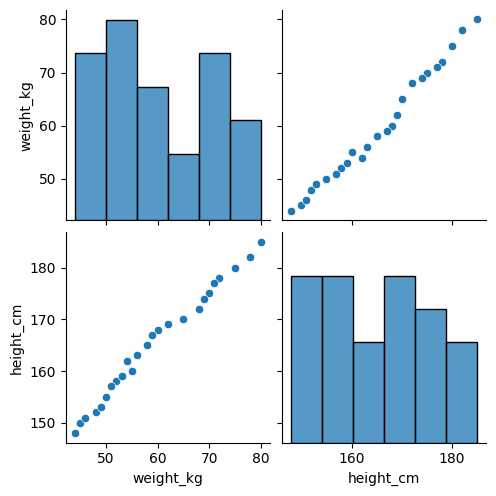

In [29]:
import seaborn as sns
sns.pairplot(df)    

In [31]:
#independent and dependent features
X = df[['weight_kg']]
y = df['height_cm']

In [32]:
# Train test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.25, random_state=42)

In [33]:
X_train.shape, y_train.shape

((18, 1), (18,))

In [34]:
## Standardization
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [35]:
## Apply Linear Regression
from sklearn.linear_model import LinearRegression
model = LinearRegression() # create an instance of the LinearRegression class
model.fit(X_train, y_train) # fit the model to the training data
y_pred = model.predict(X_test) # make predictions on the test data 

In [37]:
## print the coefficients and intercept of the linear regression model
print('Coefficient:', model.coef_)
print('Intercept:', model.intercept_)


Coefficient: [9.83072802]
Intercept: 164.05555555555554


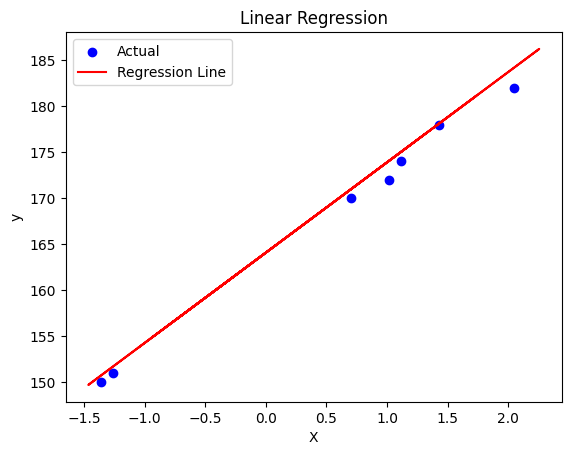

In [36]:
## Plotting the regression line
plt.scatter(X_test, y_test, color='blue', label='Actual')
plt.plot(X_train, model.predict(X_train), color='red', label='Regression Line')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Linear Regression')
plt.legend()
plt.show()

In [38]:
## Permormance metrics
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, adjusted_rand_score, root_mean_squared_error
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
adj_r2 = adjusted_rand_score(y_test, y_pred)

print('Mean Squared Error:', mse)
print('R-squared:', r2)
print('Mean Absolute Error:', mae)
print('Root Mean Squared Error:', rmse)
print('Adjusted R-squared:', adj_r2)


Mean Squared Error: 1.7260367662925589
R-squared: 0.9874776722611289
Mean Absolute Error: 1.1116758196509042
Root Mean Squared Error: 1.3137871845518052
Adjusted R-squared: 1.0


/Users/amanverma/My PC/Coding/Github/dsml-projects/myenv/lib/python3.9/site-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received multiclass values for label, and continuous values for target
  warnings.warn(msg, UserWarning)


In [39]:
##  OLS (Ordinary Least Squares) method Linear Regrsession
import statsmodels.api as sm
model = sm.OLS(y_train, X_train).fit()
print(model.summary())

ModuleNotFoundError: No module named 'statsmodels'

In [41]:
## Prediction for new data 
model.predict(scaler.transform([[70]]))

/Users/amanverma/My PC/Coding/Github/dsml-projects/myenv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([176.07365682])